滤波器系数 (SOS):
[[ 7.53777277e-04  1.44822196e-03  7.53777277e-04  1.00000000e+00
  -1.17868875e+00  3.86092299e-01]
 [ 1.00000000e+00  1.44096611e+00  1.00000000e+00  1.00000000e+00
  -9.45476000e-01  5.05092520e-01]
 [ 1.00000000e+00  9.13595523e-01  1.00000000e+00  1.00000000e+00
  -6.42539635e-01  6.59696220e-01]
 [ 1.00000000e+00  5.43587646e-01  1.00000000e+00  1.00000000e+00
  -3.92846351e-01  7.87190968e-01]
 [ 1.00000000e+00  3.20127904e-01  1.00000000e+00  1.00000000e+00
  -2.23822643e-01  8.73623279e-01]
 [ 1.00000000e+00  1.91887539e-01  1.00000000e+00  1.00000000e+00
  -1.19686144e-01  9.27114554e-01]
 [ 1.00000000e+00  1.19816171e-01  1.00000000e+00  1.00000000e+00
  -5.86675362e-02  9.58896075e-01]
 [ 1.00000000e+00  8.01320614e-02  1.00000000e+00  1.00000000e+00
  -2.42574636e-02  9.77614596e-01]
 [ 1.00000000e+00  5.94029577e-02  1.00000000e+00  1.00000000e+00
  -6.03786865e-03  9.88985898e-01]
 [ 1.00000000e+00  5.05530762e-02  1.00000000e+00  1.00000000e+00
   1.8044278

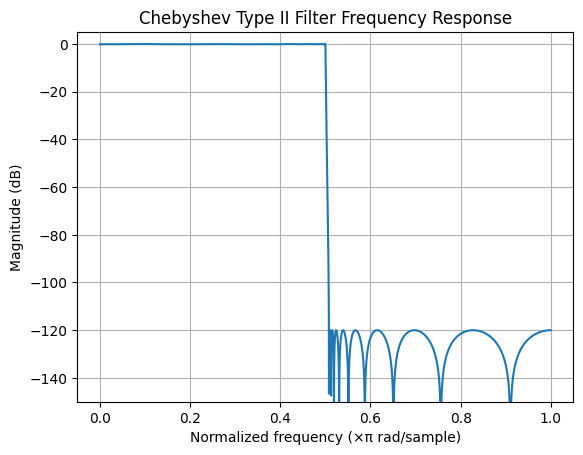

In [26]:
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt

# 32阶切比雪夫2型低通滤波器
order = 20          # 阶数
rs = 120            # 阻带衰减 (dB)
atten = 3           # 1rad/s处的衰减(0.5采样率相当于pi/2)

if atten >= rs:
    raise RuntimeError('atten < ripple')

fscale = np.cosh(np.acosh(np.sqrt((np.pow(10.0, rs / 10.0) - 1.0) / (np.pow(10.0, atten / 10.0) - 1.0))) / (order))
w = np.atan(fscale) / (2 * np.pi)

# 使用二阶节形式 (sos) 保证数值稳定性
# sos = signal.cheby2(order, rs, w, fs=0.5, output='sos')
sos = signal.ellip(order, 0.1, rs, 0.5, fs=2, output='sos')

print("滤波器系数 (SOS):")
print(sos)

# 频率响应
w, h = signal.sosfreqz(sos, worN=4096)
plt.figure()
plt.plot(w / np.pi, 20 * np.log10(np.abs(h)))
plt.title("Chebyshev Type II Filter Frequency Response")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-150, 5)
plt.show()

Partial fraction expansion (parallel form):
Residues (r):
 [ 0.08287478-8.75209540e-01j  0.08287478+8.75209540e-01j
 -0.22473231+5.76388047e-01j -0.22473231-5.76388047e-01j
  0.25813265-2.66256142e-01j  0.25813265+2.66256142e-01j
 -0.19866395+7.04629023e-02j -0.19866395-7.04629023e-02j
  0.11597368+1.74723075e-02j  0.11597368-1.74723074e-02j
 -0.0504648 -3.95598232e-02j -0.0504648 +3.95598234e-02j
  0.01189813+3.19046274e-02j  0.01189812-3.19046282e-02j
  0.00408727-1.64446947e-02j  0.00408727+1.64446926e-02j
 -0.00563598-4.38545807e-03j -0.00563598+4.38545910e-03j
  0.00193488+5.51702368e-05j  0.00193488-5.51707192e-05j]

Poles (p):
 [ 0.58934437+0.19688959j  0.58934437-0.19688959j  0.472738  +0.53067062j
  0.472738  -0.53067062j  0.32126982+0.74597716j  0.32126982-0.74597716j
  0.19642318+0.86522188j  0.19642318-0.86522188j  0.11191132+0.92795428j
  0.11191132-0.92795428j  0.05984304+0.96100642j  0.05984304-0.96100642j
  0.02933391+0.97879302j  0.02933391-0.97879302j  0.01212836+0.98

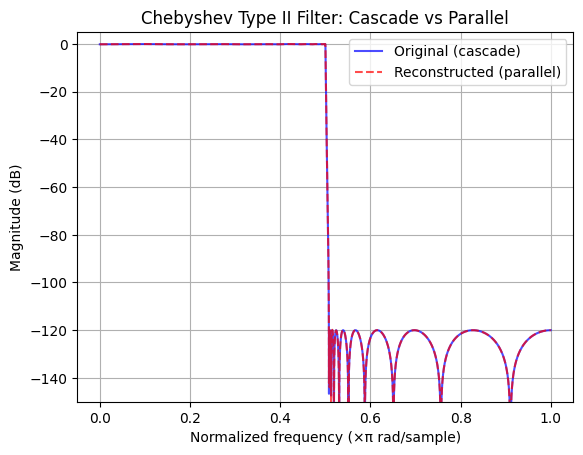

In [27]:
# Convert cascade (series) filter to parallel form using partial fraction expansion
# First, convert SOS to transfer function polynomials
b, a = signal.sos2tf(sos)

# Compute residues, poles, and direct term
residues, poles, direct_term = signal.residuez(b, a)

# Print the results
print("Partial fraction expansion (parallel form):")
print("Residues (r):\n", residues)
print("\nPoles (p):\n", poles)
print("\nDirect term:\n", direct_term)

# Verify the parallel form by reconstructing frequency response
# Use the same frequency points w from the original plot
z = np.exp(1j * w)
H_parallel = direct_term * np.ones_like(z)
for r, p in zip(residues, poles):
    H_parallel += r / (1 - p * z**-1)

# Plot comparison of original and parallel frequency responses
plt.figure()
plt.plot(w / np.pi, 20 * np.log10(np.abs(h)), 'b-', label='Original (cascade)', alpha=0.7)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H_parallel)), 'r--', label='Reconstructed (parallel)', alpha=0.7)
plt.title("Chebyshev Type II Filter: Cascade vs Parallel")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid()
plt.ylim(-150, 5)
plt.show()

In [28]:
a = []
b = []
c = []
d = []

for i in range(0, len(residues), 2):
    p = poles[i]
    pdot = poles[i + 1]
    r = residues[i]
    rdot = residues[i + 1]

    a.append(np.real(r + rdot))
    b.append(np.real(r * pdot + rdot * p))
    c.append(np.real(p + pdot))
    d.append(np.real(p * pdot))

# Print a, b, c, d as C float arrays
for name, arr in [('a', a), ('b', b), ('c', c), ('d', d)]:
    print(f"static constexpr float {name}[{len(arr)}]{{")
    elements = ", ".join(f"{v:.10e}f" for v in arr)
    print("    " + elements + "};")
    print()


static constexpr float a[10]{
    1.6574956863e-01f, -4.4946462011e-01f, 5.1626530259e-01f, -3.9732789152e-01f, 2.3194735135e-01f, -1.0092960601e-01f, 2.3796249319e-02f, 8.1745353265e-03f, -1.1271962217e-02f, 3.8697627207e-03f};

static constexpr float b[10]{
    -2.4695571071e-01f, 3.9926539486e-01f, -2.3138154268e-01f, 4.3887683681e-02f, 5.8384540151e-02f, -8.2074422876e-02f, 6.3154090954e-02f, -3.2417582617e-02f, 8.6884116301e-03f, -1.1365023712e-04f};

static constexpr float c[10]{
    1.1786887458e+00f, 9.4547600008e-01f, 6.4253963534e-01f, 3.9284635087e-01f, 2.2382264913e-01f, 1.1968608563e-01f, 5.8667826590e-02f, 2.4256723221e-02f, 6.0386857175e-03f, -1.8047429878e-03f};

static constexpr float d[10]{
    3.8609229860e-01f, 5.0509252022e-01f, 6.5969622012e-01f, 7.8719096750e-01f, 8.7362328210e-01f, 9.2711452523e-01f, 9.5889624968e-01f, 9.7761400992e-01f, 9.8898685400e-01f, 9.9669232049e-01f};

